# Importing data and libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins
import numpy as np
from statsmodels.iolib.tableformatting import fmt2

In [2]:
data = load_penguins()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


# Visualizations

## Pandas

In [3]:
# Stack bars
# summary = data.groupby('species').agg({'bill_length_mm': 'mean', 'bill_depth_mm': 'mean', 'flipper_length_mm': 'mean'})
# summary.plot(kind='bar', stacked=True, ax=ax[4, 1], color=['red', 'blue', 'green'], width=0.5)
# ax[4, 1].set_title('Stack bars - OPTION 1')
# ax[4, 1].set_xticklabels(species, rotation=0)
# ax[4, 1].set_xlabel('Species')
# ax[4, 1].set_ylabel('Mean')

## Matplotlib

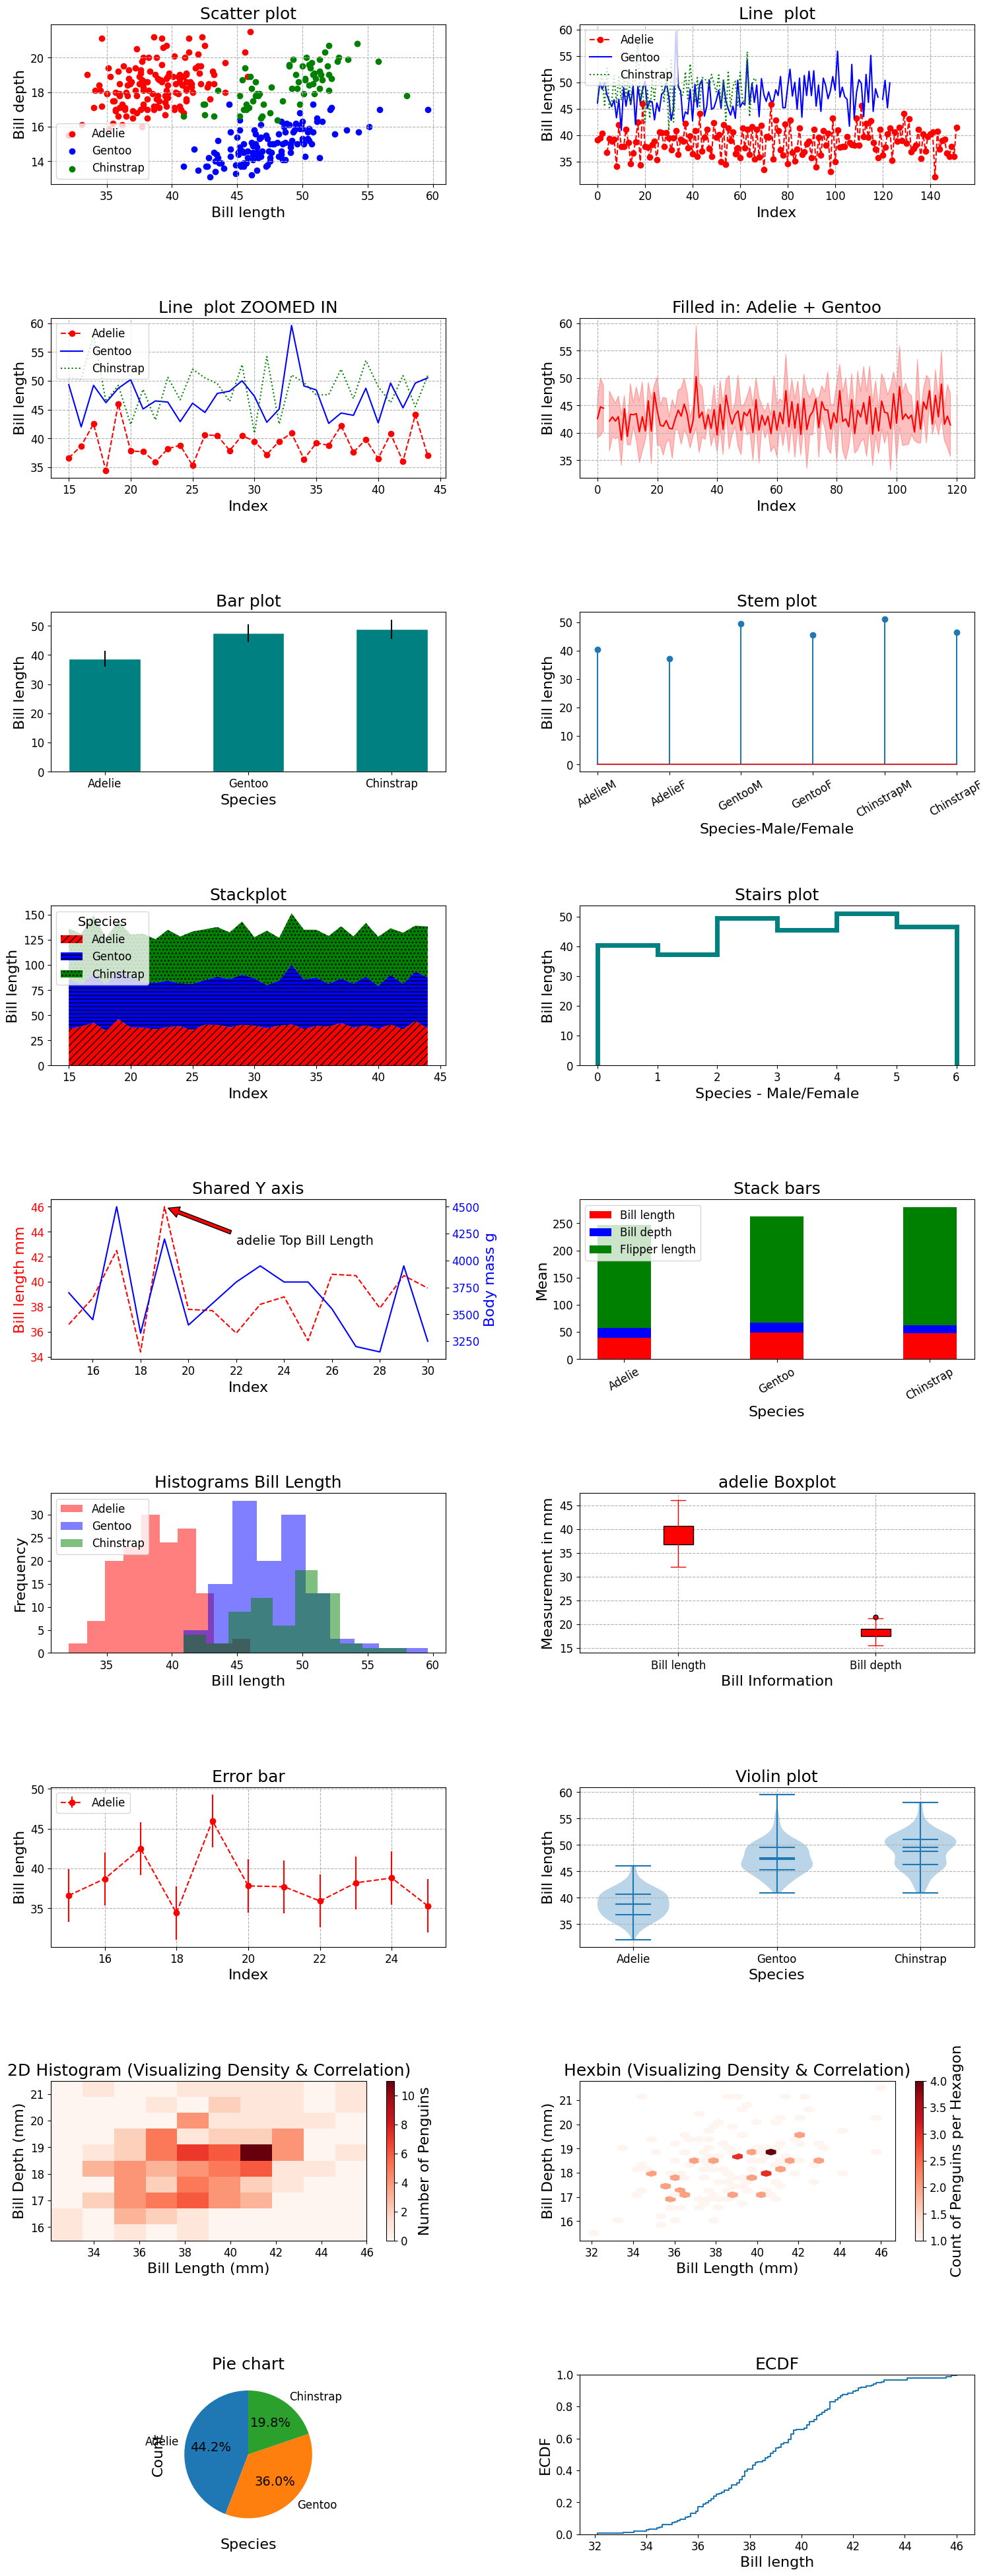

In [4]:
adelie = data[data.species == 'Adelie']
gentoo = data[data.species == 'Gentoo']
chinstrap = data[data.species == 'Chinstrap']

plt.rc('font', size=14)          # Controls default text sizes
plt.rc('axes', titlesize=18)     # Size of the subplot titles
plt.rc('axes', labelsize=16)     # Size of the x and y labels
plt.rc('xtick', labelsize=12)    # Size of the tick labels
plt.rc('ytick', labelsize=12)    # Size of the tick labels
plt.rc('legend', fontsize=12)    # Legend text size

fig, ax = plt.subplots(9, 2, figsize=(16, 40))

# Scatter plot
ax[0, 0].scatter(adelie.bill_length_mm, adelie.bill_depth_mm, color='red', label='Adelie')
ax[0, 0].scatter(gentoo.bill_length_mm, gentoo.bill_depth_mm, color='blue', label='Gentoo')
ax[0, 0].scatter(chinstrap.bill_length_mm, chinstrap.bill_depth_mm, color='green', label='Chinstrap')
ax[0, 0].legend(loc='lower left')
ax[0, 0].set_title('Scatter plot')
ax[0, 0].set_xlabel('Bill length')
ax[0, 0].set_ylabel('Bill depth')
ax[0, 0].grid(True, linestyle='--', which='major', axis='both')

# Line plot
ax[0, 1].plot(np.arange(0, adelie.shape[0]), adelie['bill_length_mm'], color='red', label='Adelie', linestyle='--', marker='o')
ax[0, 1].plot(np.arange(0, gentoo.shape[0]), gentoo['bill_length_mm'], color='blue', label='Gentoo', linestyle='-')
ax[0, 1].plot(np.arange(0, chinstrap.shape[0]), chinstrap['bill_length_mm'], color='green', label='Chinstrap', linestyle=':')
ax[0, 1].legend(loc='upper left')
ax[0, 1].set_title('Line  plot')
ax[0, 1].set_xlabel('Index')
ax[0, 1].set_ylabel('Bill length')
ax[0, 1].grid(True, linestyle='--', which='major', axis='both')

# Line plot ZOOMED IN
zoomed_in = np.arange(15, 45)
ax[1,0].plot(zoomed_in, adelie['bill_length_mm'].iloc[15:45], color='red', label='Adelie', linestyle='--', marker='o')
ax[1,0].plot(zoomed_in, gentoo['bill_length_mm'].iloc[15:45], color='blue', label='Gentoo', linestyle='-')
ax[1,0].plot(zoomed_in, chinstrap['bill_length_mm'].iloc[15:45], color='green', label='Chinstrap', linestyle=':')
ax[1,0].legend(loc='upper left')
ax[1,0].set_title('Line  plot ZOOMED IN')
ax[1,0].set_xlabel('Index')
ax[1,0].set_ylabel('Bill length')
ax[1,0].grid(True, linestyle='--', which='major', axis='both')

# Filled in
between = np.arange(0, 121)
adelie_120 = adelie['bill_length_mm'].iloc[0:121]
gentoo_120 = gentoo['bill_length_mm'].iloc[0:121]
ax[1, 1].fill_between(between, adelie_120, gentoo_120, color='red', alpha=0.25)
ax[1, 1].plot(between, (adelie_120.values + gentoo_120.values)/2, color='red', linestyle='-')
ax[1, 1].set_title('Filled in: Adelie + Gentoo')
ax[1, 1].set_xlabel('Index')
ax[1, 1].set_ylabel('Bill length')
ax[1, 1].grid(True, linestyle='--', which='major', axis='both')

# Bar plot (X vs. Height)
species = ['Adelie', 'Gentoo', 'Chinstrap']
bill_length_mean = [adelie.bill_length_mm.mean(), gentoo.bill_length_mm.mean(), chinstrap.bill_length_mm.mean()]
bill_length_std = [adelie.bill_length_mm.std(), gentoo.bill_length_mm.std(), chinstrap.bill_length_mm.std()]
ax[2, 0].bar(species, bill_length_mean, color='teal', edgecolor='white', width=0.5, yerr=bill_length_std)
ax[2, 0].set_title('Bar plot')
ax[2, 0].set_xlabel('Species')
ax[2, 0].set_ylabel('Bill length')

# Stem plot (useful when there are too many categorical variables)
species_sex = ['AdelieM', 'AdelieF', 'GentooM', 'GentooF', 'ChinstrapM', 'ChinstrapF']
bill_length_sex = [adelie.query('sex == "male"').bill_length_mm.mean(), adelie.query('sex == "female"').bill_length_mm.mean(), gentoo.query('sex == "male"').bill_length_mm.mean(), gentoo.query('sex == "female"').bill_length_mm.mean(), chinstrap.query('sex == "male"').bill_length_mm.mean(), chinstrap.query('sex == "female"').bill_length_mm.mean()]
ax[2, 1].stem(species_sex, bill_length_sex)
ax[2, 1].set_title('Stem plot')
ax[2, 1].set_xticks(range(len(species_sex)))
ax[2, 1].set_xticklabels(species_sex, rotation=30)
ax[2, 1].set_xlabel('Species-Male/Female')
ax[2, 1].set_ylabel('Bill length')

# Stack plot
bill_zoom_matrix = np.vstack([adelie['bill_length_mm'].iloc[15:45], gentoo['bill_length_mm'].iloc[15:45], chinstrap['bill_length_mm'].iloc[15:45]])
ax[3, 0].stackplot(zoomed_in, bill_zoom_matrix, labels=['Adelie', 'Gentoo', 'Chinstrap'], baseline='zero', colors=['red', 'blue', 'green'], hatch=['///', '---', '...'])
ax[3, 0].set_title('Stackplot')
ax[3, 0].set_xlabel('Index')
ax[3, 0].set_ylabel('Bill length')
ax[3, 0].legend(loc='upper left', title='Species')

# Stairs
ax[3, 1].stairs(bill_length_sex, linewidth=5, fill=False, color='teal', orientation='vertical')
ax[3, 1].set_title('Stairs plot')
ax[3, 1].set_xlabel('Species - Male/Female')
ax[3, 1].set_ylabel('Bill length')

# Shared Y axis
zoomed_in = np.arange(15, 31)
ax[4, 0].plot(zoomed_in, adelie['bill_length_mm'].iloc[15:31], color='red', linestyle='--')
ax[4, 0].set_title('Shared Y axis')
ax[4, 0].set_xlabel('Index')
ax[4, 0].set_ylabel('Bill length mm', color='red')
ax[4, 0].tick_params(axis='y', labelcolor='red')
ax[4, 0].annotate('adelie Top Bill Length', xy=(19, 46), xytext=(22, 43), arrowprops=dict(facecolor='red', shrink=0.05))

ax2 = ax[4, 0].twinx()
ax2.plot(zoomed_in, adelie['body_mass_g'].iloc[15:31], color='blue', linestyle='-')
ax2.set_ylabel('Body mass g', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Stack bars
summary = data.groupby('species').agg({'bill_length_mm': 'mean', 'bill_depth_mm': 'mean', 'flipper_length_mm': 'mean'})
ax[4, 1].bar(summary.index, summary['bill_length_mm'], width=0.35, label='Bill length', color='red')
ax[4, 1].bar(summary.index, summary['bill_depth_mm'], bottom=summary['bill_length_mm'], width=0.35, label='Bill depth', color='blue')
ax[4, 1].bar(summary.index, summary['flipper_length_mm'], bottom=summary['bill_length_mm'] + summary['bill_depth_mm'], width=0.35, label='Flipper length', color='green')
ax[4, 1].legend(loc='upper left')
ax[4, 1].set_title('Stack bars')
ax[4, 1].set_xticks(range(len(species)))
ax[4, 1].set_xticklabels(species, rotation=30)
ax[4, 1].set_xlabel('Species')
ax[4, 1].set_ylabel('Mean')

# Histograms
ax[5, 0].hist(adelie['bill_length_mm'], bins=10, color='red', alpha=0.5, label='Adelie', histtype='bar')
ax[5, 0].hist(gentoo['bill_length_mm'], bins=10, color='blue', alpha=0.5, label='Gentoo', histtype='bar')
ax[5, 0].hist(chinstrap['bill_length_mm'], bins=10, color='green', alpha=0.5, label='Chinstrap', histtype='bar')
ax[5, 0].legend(loc='upper left')
ax[5, 0].set_title('Histograms Bill Length')
ax[5, 0].set_xlabel('Bill length')
ax[5, 0].set_ylabel('Frequency')

# Boxplot
ax[5, 1].boxplot([adelie['bill_length_mm'].ffill(), adelie['bill_depth_mm'].ffill()], tick_labels=['Bill length', 'Bill depth'], patch_artist=True, boxprops=dict(facecolor='red'), whiskerprops=dict(color='red'), flierprops=dict(marker='o', markerfacecolor='red', markersize=5), medianprops=dict(color='red'), capprops=dict(color='red'))
ax[5, 1].set_title('adelie Boxplot')
ax[5, 1].set_xlabel('Bill Information')
ax[5, 1].set_ylabel('Measurement in mm')
ax[5, 1].grid(True, linestyle='--', which='major', axis='both')

# Error bar
ax[6,0].errorbar(np.arange(15, 26), adelie['bill_length_mm'].iloc[15:26], yerr=adelie['bill_length_mm'].iloc[15:26].std(), color='red', linestyle='--', marker='o', label='Adelie')
ax[6,0].legend(loc='upper left')
ax[6,0].set_title('Error bar')
ax[6,0].set_xlabel('Index')
ax[6,0].set_ylabel('Bill length')
ax[6,0].grid(True, linestyle='--', which='major', axis='both')

# Violin plot
quantiles = [[0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1]]
ax[6, 1].violinplot([adelie['bill_length_mm'].ffill(), gentoo['bill_length_mm'].ffill(), chinstrap['bill_length_mm'].ffill()], showmeans=True, showmedians=True, showextrema=True, quantiles=quantiles)
ax[6, 1].set_title('Violin plot')
ax[6, 1].set_xlabel('Species')
ax[6, 1].set_ylabel('Bill length')
ax[6, 1].grid(True, linestyle='--', which='major', axis='both')
ax[6, 1].set_xticks([1, 2, 3])
ax[6, 1].set_xticklabels(['Adelie', 'Gentoo', 'Chinstrap'])

# Histogram 2D
counts, xedges, yedges, im = ax[7, 0].hist2d(adelie['bill_length_mm'].ffill(), adelie['bill_depth_mm'].ffill(), bins=10, cmap='Reds')
fig.colorbar(im, ax=ax[7, 0], label='Number of Penguins')
ax[7, 0].set_title('2D Histogram (Visualizing Density & Correlation)')
ax[7, 0].set_xlabel('Bill Length (mm)')
ax[7, 0].set_ylabel('Bill Depth (mm)')

# Hexbin
# counts, xedges, yedges, im = ax[7, 1].hexbin(adelie['bill_length_mm'].ffill(), adelie['bill_depth_mm'].ffill(), bins=10, cmap='Reds')
# fig.colorbar(im, ax=ax[7, 1], label='Number of Penguins')
hb = ax[7, 1].hexbin(adelie['bill_length_mm'].ffill(), adelie['bill_depth_mm'].ffill(), gridsize=30, cmap='Reds', mincnt=1)
fig.colorbar(hb, ax=ax[7,1], label='Count of Penguins per Hexagon')
ax[7, 1].set_title('Hexbin (Visualizing Density & Correlation)')
ax[7, 1].set_xlabel('Bill Length (mm)')
ax[7, 1].set_ylabel('Bill Depth (mm)')

# Pie chart
species_count = data.species.value_counts()
ax[8, 0].pie(species_count, labels=species_count.index, autopct='%1.1f%%', startangle=90)
ax[8, 0].set_title('Pie chart')
ax[8, 0].set_xlabel('Species')
ax[8, 0].set_ylabel('Count')

# ECDF
ax[8, 1].ecdf(adelie['bill_length_mm'].ffill(), label='Adelie')
ax[8, 1].set_title('ECDF')
ax[8, 1].set_xlabel('Bill length')
ax[8, 1].set_ylabel('ECDF')

plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=3.0)
plt.show()

## Seaborn

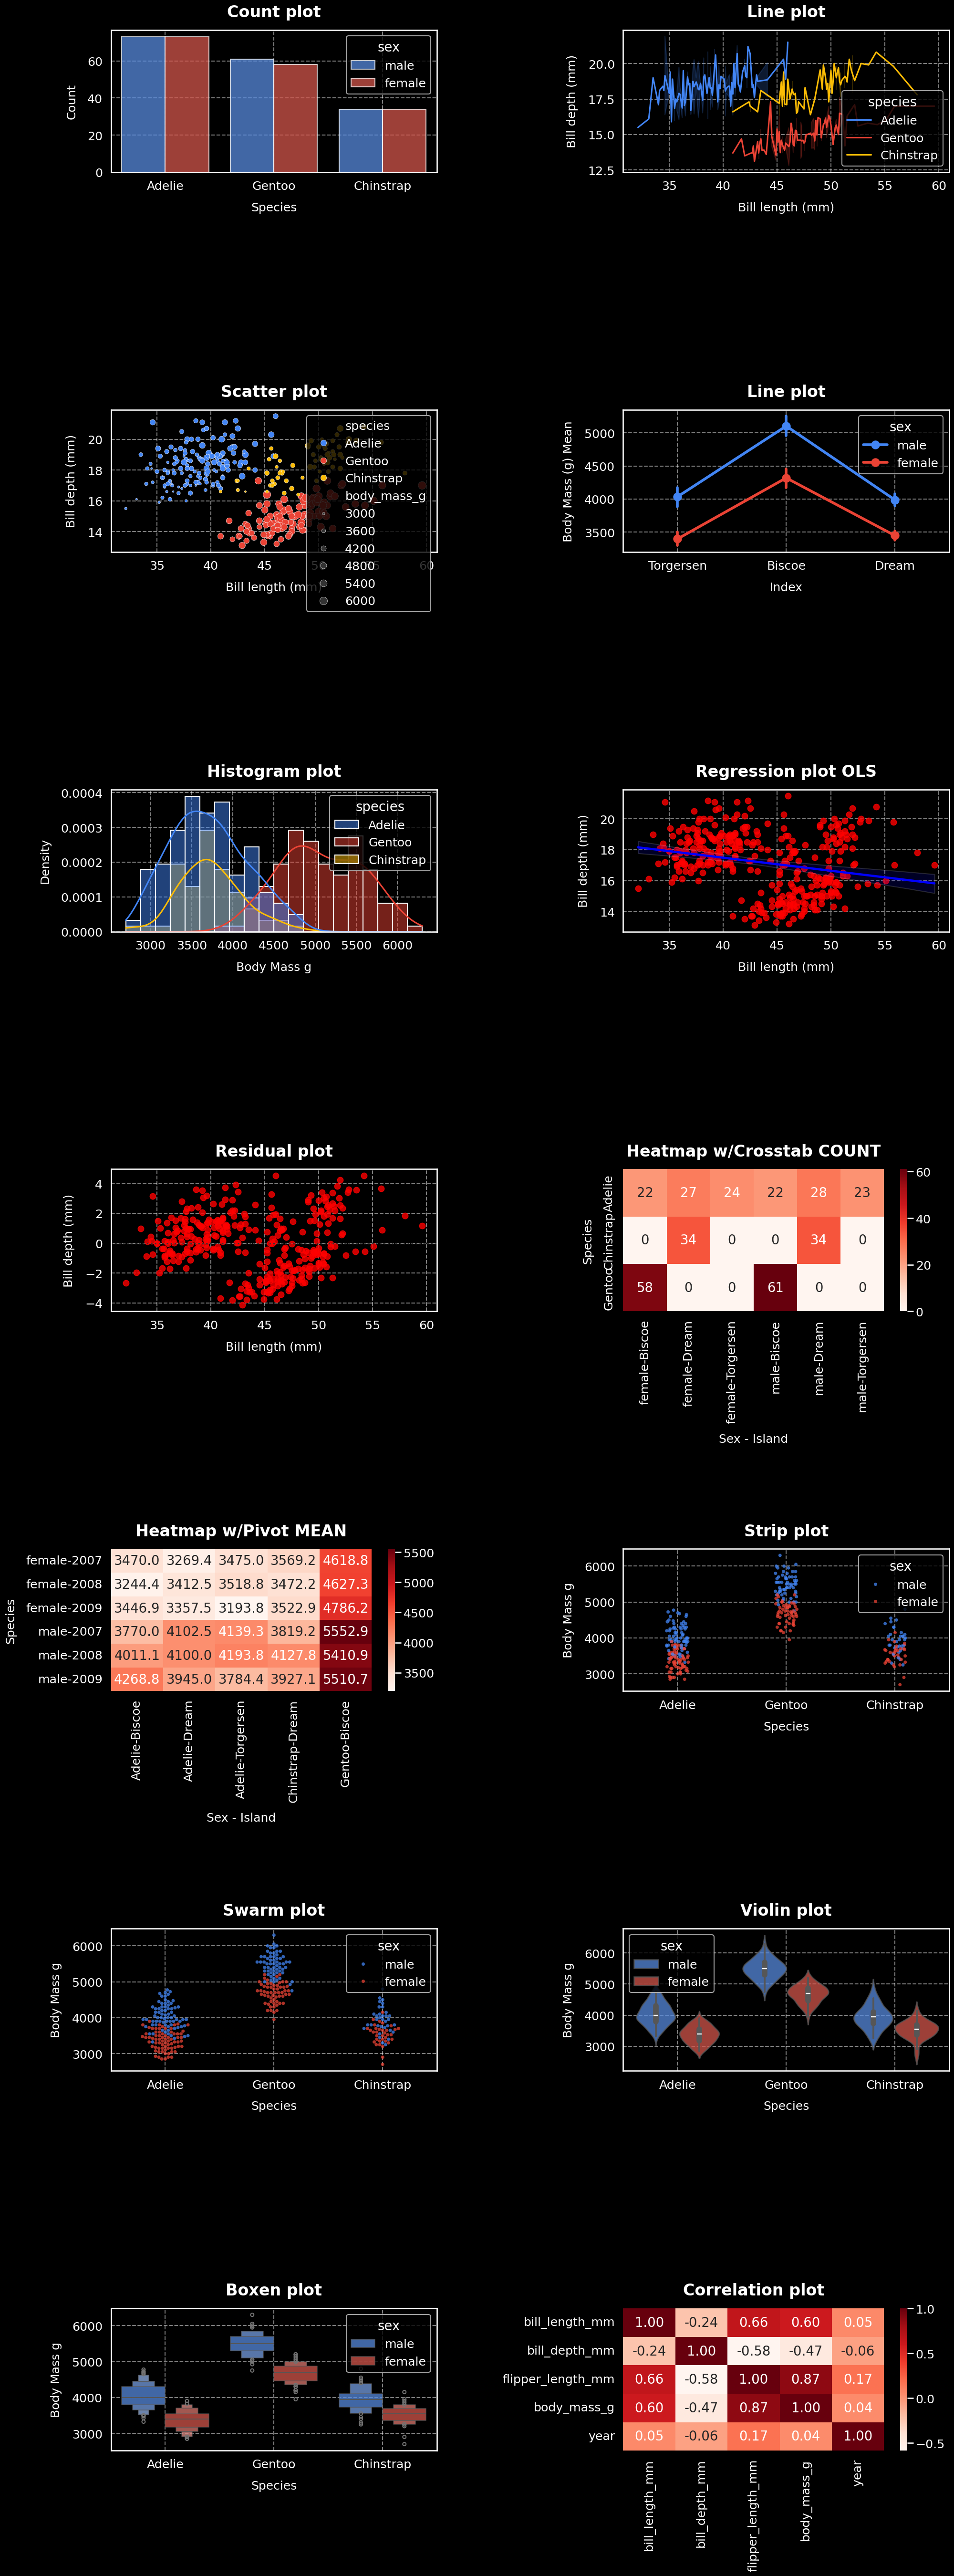

In [38]:
sns.set_context("talk", font_scale=1.1)

# 2. THEME FIX: Set dark style using Seaborn so both Matplotlib and Seaborn styles align perfectly
sns.set_style("darkgrid", {
    "background.color": "#111111",
    "axes.facecolor": "#1c1c1c",
    "grid.color": "#444444"
})
plt.style.use('dark_background')

fig, axes = plt.subplots(7, 2, figsize=(22, 56))

plt.style.use('dark_background')
# sns.set_theme(style="darkgrid")
google_colors = ["#4285F4", "#EA4335", "#FBBC05", "#34A853"]
google_three = ["#4285F4", "#EA4335", "#FBBC05"]
sns.set_palette(google_colors)

# Count plot
sns.countplot(data=data, x="species", ax=axes[0, 0], hue='sex', alpha=0.75)
axes[0, 0].set_title('Count plot', pad=20, fontsize=24, fontweight='bold')
axes[0, 0].set_xlabel('Species', labelpad=15, fontsize=18)
axes[0, 0].set_ylabel('Count', labelpad=15, fontsize=18)
axes[0, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Line plot
sns.lineplot(data=data, x="bill_length_mm", y="bill_depth_mm", ax=axes[0, 1], hue='species', hue_order=['Adelie', 'Gentoo', 'Chinstrap'], errorbar='sd')
axes[0, 1].set_title('Line plot', pad=20, fontsize=24, fontweight='bold')
axes[0, 1].set_xlabel('Bill length (mm)', labelpad=15, fontsize=18)
axes[0, 1].set_ylabel('Bill depth (mm)', labelpad=15, fontsize=18)
axes[0, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Scatter plot
sns.scatterplot(data=data, x='bill_length_mm', y='bill_depth_mm', ax=axes[1, 0], palette=google_three, hue='species', hue_order=['Adelie', 'Gentoo', 'Chinstrap'], size='body_mass_g', sizes=(1, 150))
axes[1, 0].set_title('Scatter plot', pad=20, fontsize=24, fontweight='bold')
axes[1, 0].set_xlabel('Bill length (mm)', labelpad=15, fontsize=18)
axes[1, 0].set_ylabel('Bill depth (mm)', labelpad=15, fontsize=18)
axes[1, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Line plot
sns.pointplot(data=data, x='island', y="body_mass_g", hue="sex", ax=axes[1, 1], estimator='mean')
axes[1, 1].set_title('Line plot', pad=20, fontsize=24, fontweight='bold')
axes[1, 1].set_xlabel('Index', labelpad=15, fontsize=18)
axes[1, 1].set_ylabel('Body Mass (g) Mean', labelpad=15, fontsize=18)
axes[1, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Histogram
sns.histplot(data=data, x='body_mass_g', hue='species', palette=google_three, kde=True, bins=20, ax=axes[2, 0], legend=True, stat='density')
axes[2, 0].set_title('Histogram plot', pad=20, fontsize=24, fontweight='bold')
axes[2, 0].set_xlabel('Body Mass g', labelpad=15, fontsize=18)
axes[2, 0].set_ylabel('Density', labelpad=15, fontsize=18)
axes[2, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Regression plot
sns.regplot(data=data, x="bill_length_mm", y="bill_depth_mm", ax=axes[2, 1], color='red', scatter=True, line_kws={'color': 'blue'}, order=1)
axes[2, 1].set_title('Regression plot OLS', pad=20, fontsize=24, fontweight='bold')
axes[2, 1].set_xlabel('Bill length (mm)', labelpad=15, fontsize=18)
axes[2, 1].set_ylabel('Bill depth (mm)', labelpad=15, fontsize=18)
axes[2, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Residual plot
sns.residplot(data=data, x="bill_length_mm", y="bill_depth_mm", ax=axes[3, 0], color='red')
axes[3, 0].set_title('Residual plot', pad=20, fontsize=24, fontweight='bold')
axes[3, 0].set_xlabel('Bill length (mm)', labelpad=15, fontsize=18)
axes[3, 0].set_ylabel('Bill depth (mm)', labelpad=15, fontsize=18)
axes[3, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Heatmap OPTION Crosstab
cross_data = pd.crosstab(data.species, [data.sex, data.island])
sns.heatmap(cross_data, annot=True, fmt='d', cmap='Reds', ax=axes[3, 1])
axes[3, 1].set_title('Heatmap w/Crosstab COUNT', pad=20, fontsize=24, fontweight='bold')
axes[3, 1].set_ylabel('Species', labelpad=15, fontsize=18)
axes[3, 1].set_xlabel('Sex - Island', labelpad=15, fontsize=18)

#  Heatmap OPTION Pivot table
pivot_table = pd.pivot_table(data=data, index=['sex', 'year'], columns=['species', 'island'], values='body_mass_g', aggfunc='mean').round(1).fillna(0)
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='Reds', ax=axes[4, 0])
axes[4, 0].set_title('Heatmap w/Pivot MEAN', pad=20, fontsize=24, fontweight='bold')
axes[4, 0].set_ylabel('Species', labelpad=15, fontsize=18)
axes[4, 0].set_xlabel('Sex - Island', labelpad=15, fontsize=18)

# Strip plot
sns.stripplot(data=data, x="species", y='body_mass_g', ax=axes[4, 1], hue='sex', alpha=0.75, )
axes[4, 1].set_title('Strip plot', pad=20, fontsize=24, fontweight='bold')
axes[4, 1].set_xlabel('Species', labelpad=15, fontsize=18)
axes[4, 1].set_ylabel('Body Mass g', labelpad=15, fontsize=18)
axes[4, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Swarm plot
sns.swarmplot(data=data, x="species", y='body_mass_g', ax=axes[5, 0], hue='sex', alpha=0.75)
axes[5, 0].set_title('Swarm plot', pad=20, fontsize=24, fontweight='bold')
axes[5, 0].set_xlabel('Species', labelpad=15, fontsize=18)
axes[5, 0].set_ylabel('Body Mass g', labelpad=15, fontsize=18)
axes[5, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Violin plot
sns.violinplot(data=data, x="species", y='body_mass_g', ax=axes[5, 1], hue='sex', alpha=0.75)
axes[5, 1].set_title('Violin plot', pad=20, fontsize=24, fontweight='bold')
axes[5, 1].set_xlabel('Species', labelpad=15, fontsize=18)
axes[5, 1].set_ylabel('Body Mass g', labelpad=15, fontsize=18)
axes[5, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Boxen plot
sns.boxenplot(data=data, x="species", y='body_mass_g', ax=axes[6, 0], hue='sex', alpha=0.75)
axes[6, 0].set_title('Boxen plot', pad=20, fontsize=24, fontweight='bold')
axes[6, 0].set_xlabel('Species', labelpad=15, fontsize=18)
axes[6, 0].set_ylabel('Body Mass g', labelpad=15, fontsize=18)
axes[6, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Correlation plot
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Reds', ax=axes[6, 1])
axes[6, 1].set_title('Correlation plot', pad=20, fontsize=24, fontweight='bold')
# axes[6, 1].set_xlabel('Species', labelpad=15, fontsize=18)
# axes[6, 1].set_ylabel('Body Mass g', labelpad=15, fontsize=18)
axes[6, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

plt.tight_layout(pad=4.0, h_pad=6.0, w_pad=5.0)
plt.show()

### Rel plot

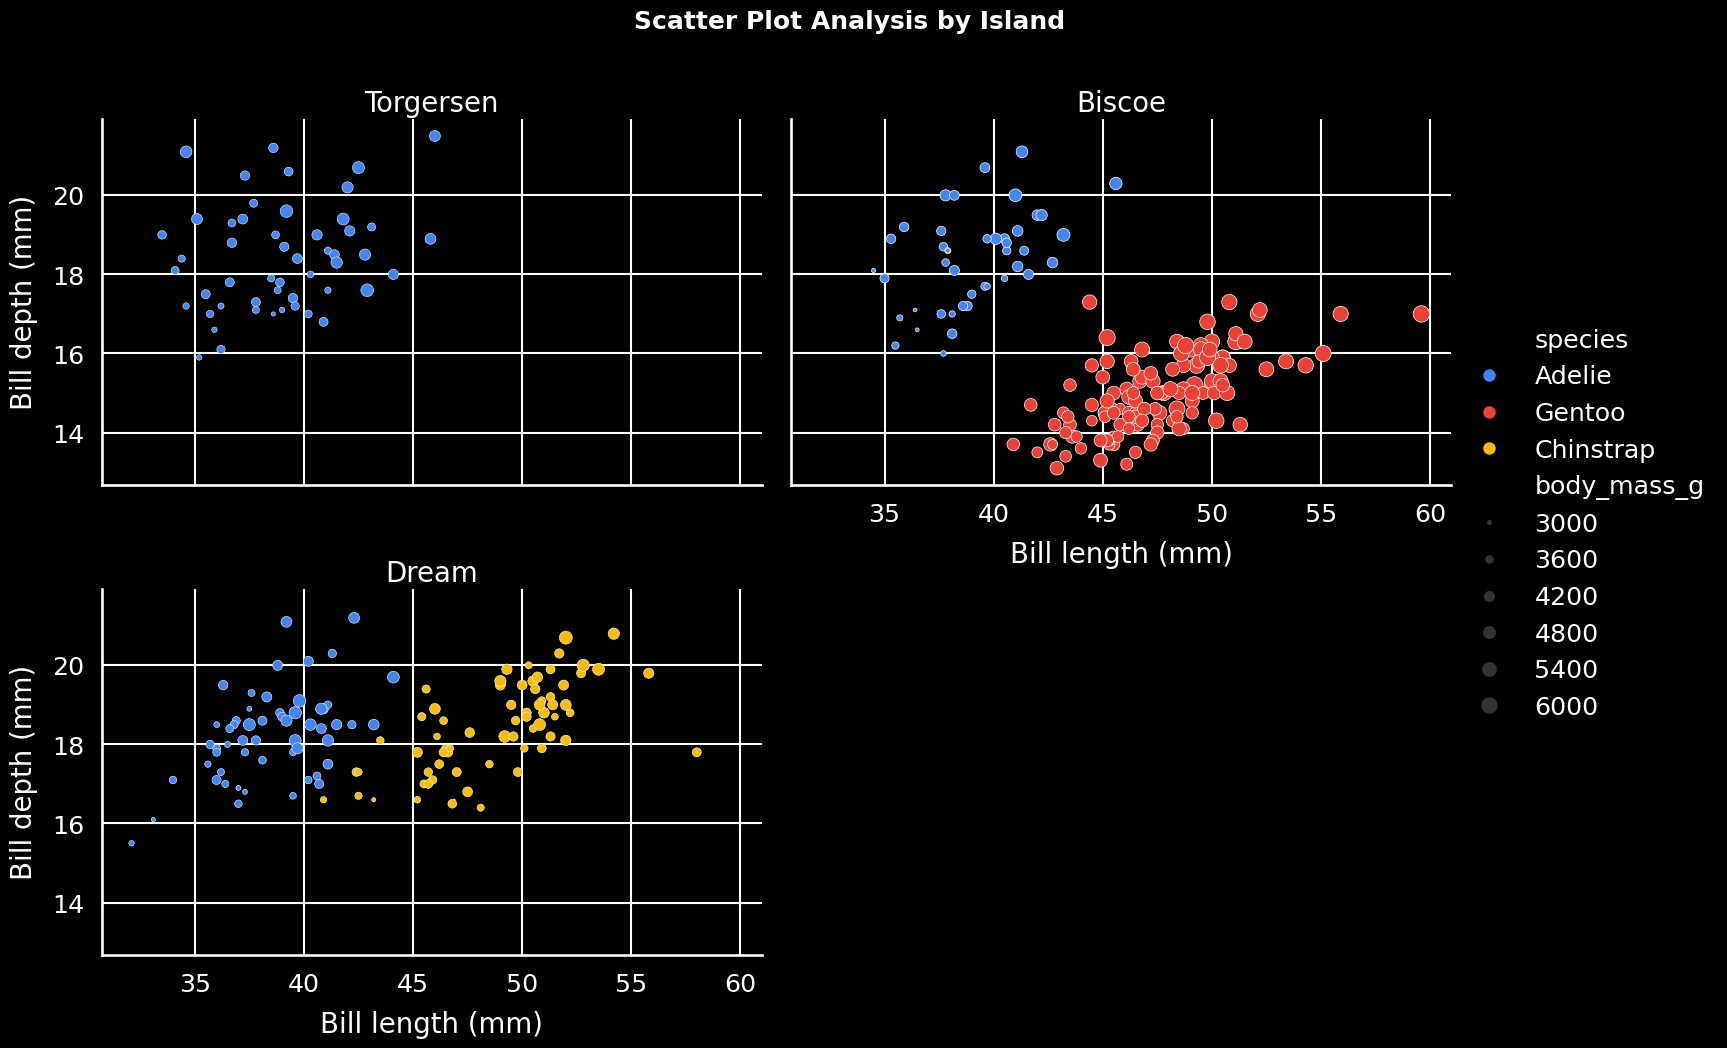

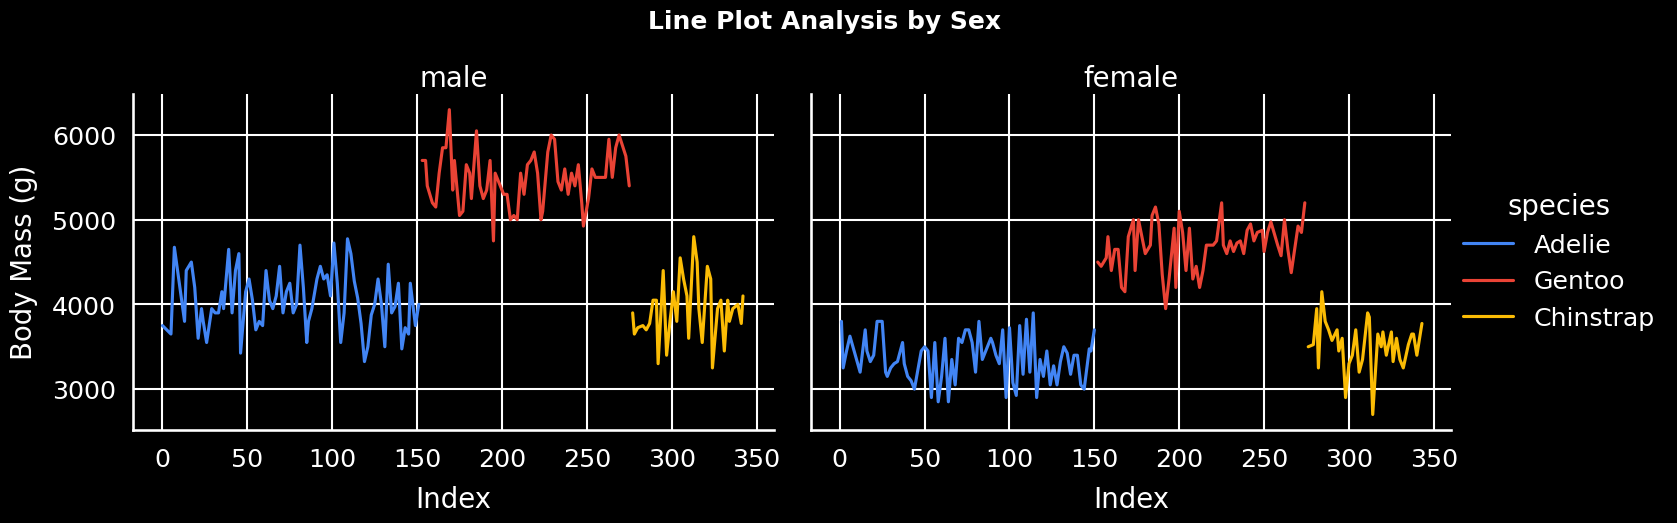

In [6]:
# Scatter plot
g = sns.relplot(data=data, x="bill_length_mm", y="bill_depth_mm", hue="species", kind="scatter", palette=google_three, size="body_mass_g", sizes=(1, 150), height=5, aspect=1.5, col='island', col_wrap=2, row_order=['Dream', 'Torgersen', 'Biscoe'])
g.set_titles('{col_name}')
g.figure.suptitle('Scatter Plot Analysis by Island', fontsize=18, fontweight='bold', y=1.05)
g.set_ylabels('Bill depth (mm)', labelpad=10)
g.set_xlabels('Bill length (mm)', labelpad=10)

# Line plot
g = sns.relplot(data=data, x=np.arange(data.shape[0]), y="body_mass_g", hue="species", kind="line", palette=google_three, height=5, aspect=1.5, col='sex', col_wrap=2,errorbar='sd')
g.set_titles('{col_name}')
g.figure.suptitle('Line Plot Analysis by Sex', fontsize=18, fontweight='bold', y=1.05)
g.set_ylabels('Body Mass (g)', labelpad=10)
g.set_xlabels('Index', labelpad=10)

### Cat plot

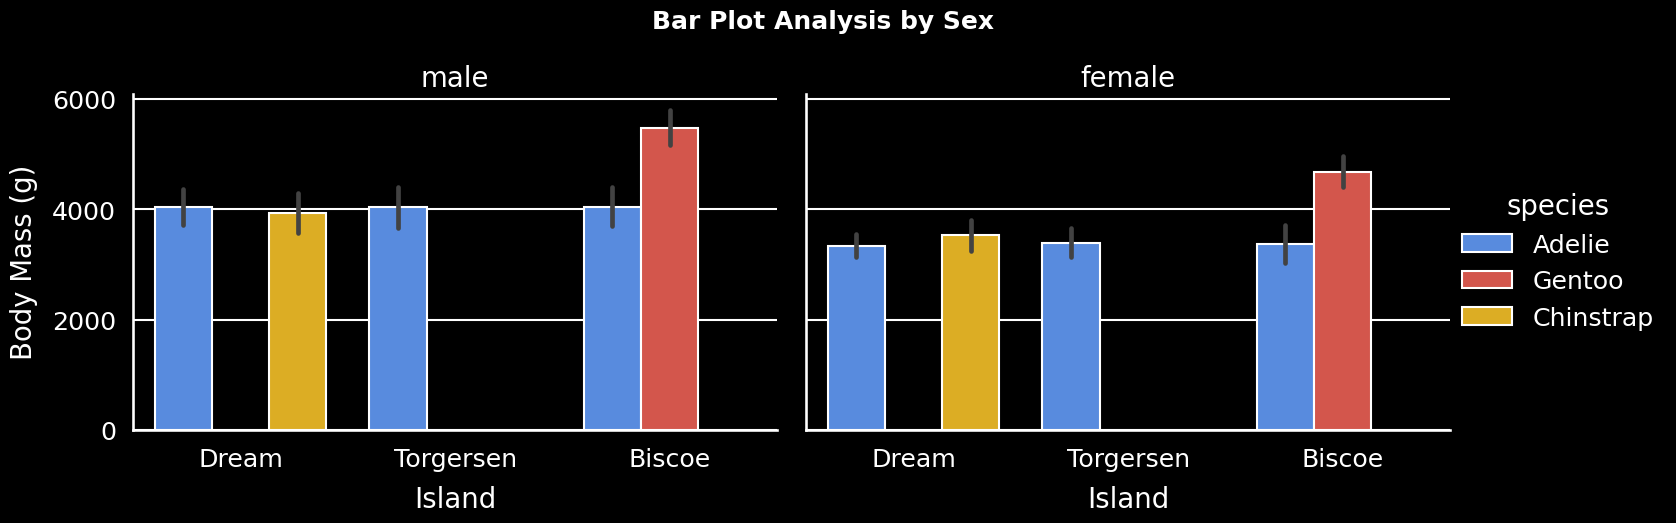

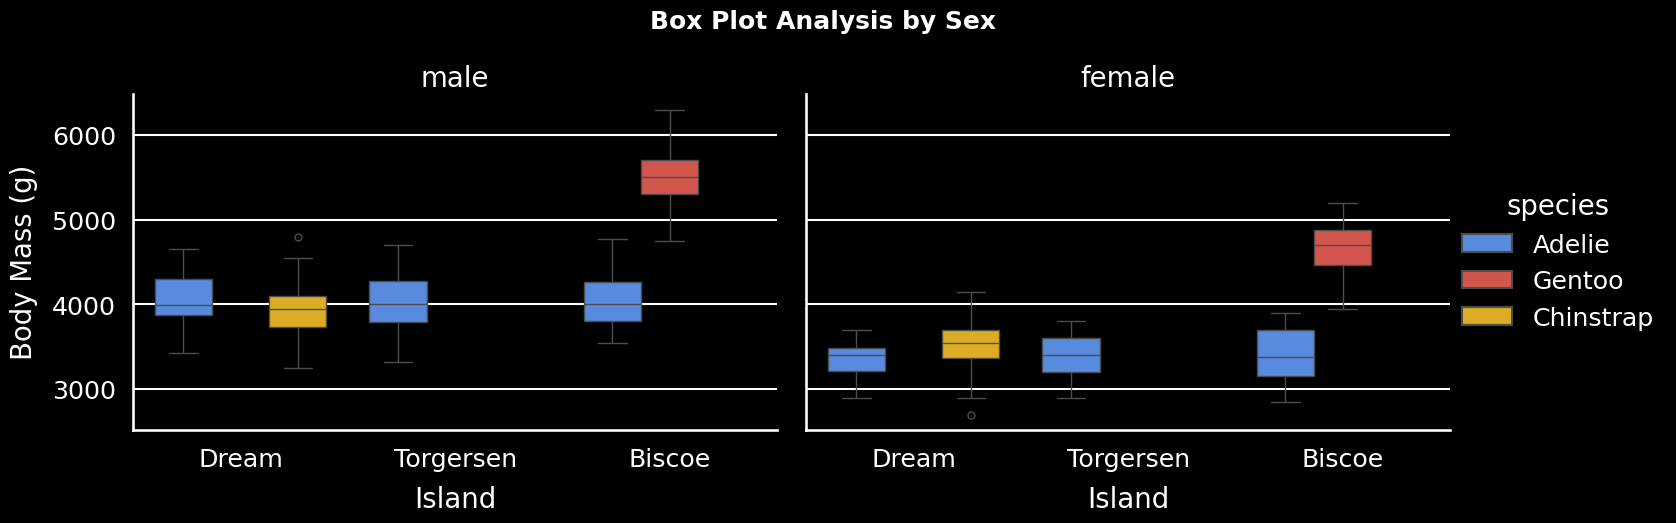

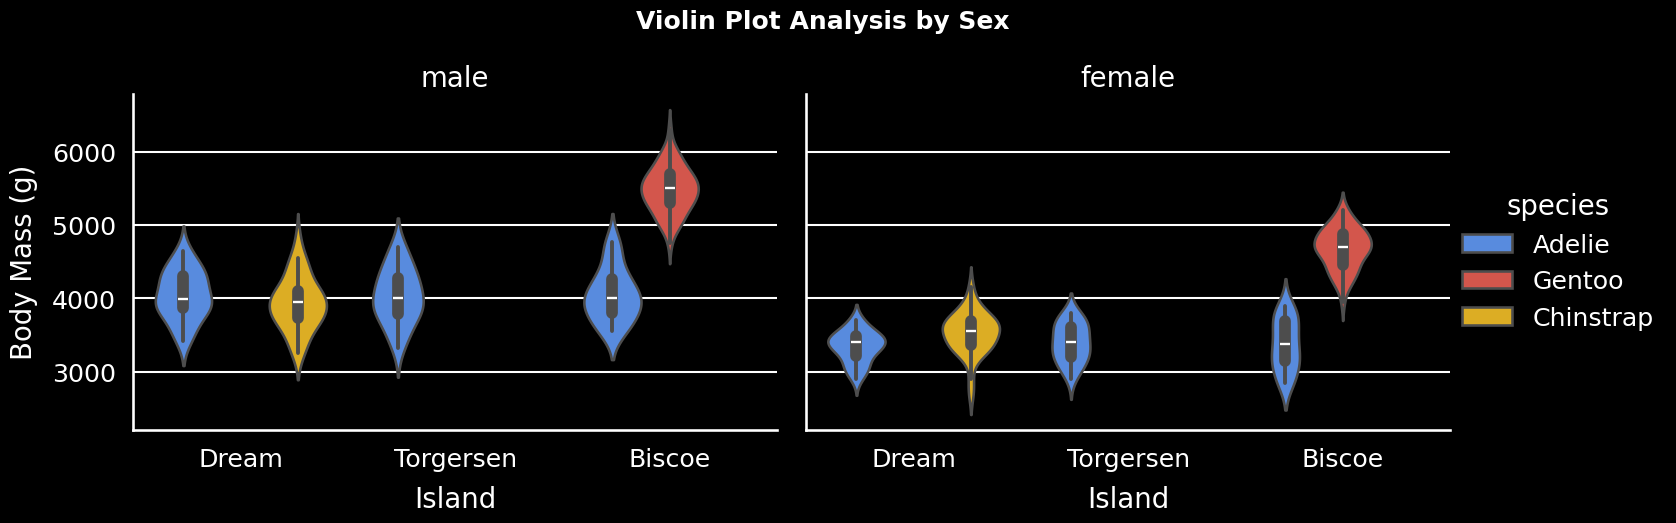

In [7]:
# Bar plot

g = sns.catplot(data=data, x='island', y='body_mass_g', kind='bar', errorbar='sd', hue='species', palette=google_three, col='sex', col_wrap=2, height=5, aspect=1.5, order=['Dream', 'Torgersen', 'Biscoe'])
g.set_titles('{col_name}')
g.figure.suptitle('Bar Plot Analysis by Sex', fontsize=18, fontweight='bold', y=1.05)
g.set_ylabels('Body Mass (g)', labelpad=10)
g.set_xlabels('Island', labelpad=10)

# Box plot
h = sns.catplot(data=data, x='island', y='body_mass_g', kind='box', hue='species', palette=google_three, col='sex', col_wrap=2, height=5, aspect=1.5, order=['Dream', 'Torgersen', 'Biscoe'])
h.set_titles('{col_name}')
h.figure.suptitle('Box Plot Analysis by Sex', fontsize=18, fontweight='bold', y=1.05)
h.set_ylabels('Body Mass (g)', labelpad=10)
h.set_xlabels('Island', labelpad=10)

# Violin plot
h = sns.catplot(data=data, x='island', y='body_mass_g', kind='violin', hue='species', palette=google_three, col='sex', col_wrap=2, height=5, aspect=1.5, order=['Dream', 'Torgersen', 'Biscoe'])
h.set_titles('{col_name}')
h.figure.suptitle('Violin Plot Analysis by Sex', fontsize=18, fontweight='bold', y=1.05)
h.set_ylabels('Body Mass (g)', labelpad=10)
h.set_xlabels('Island', labelpad=10)


### Displot

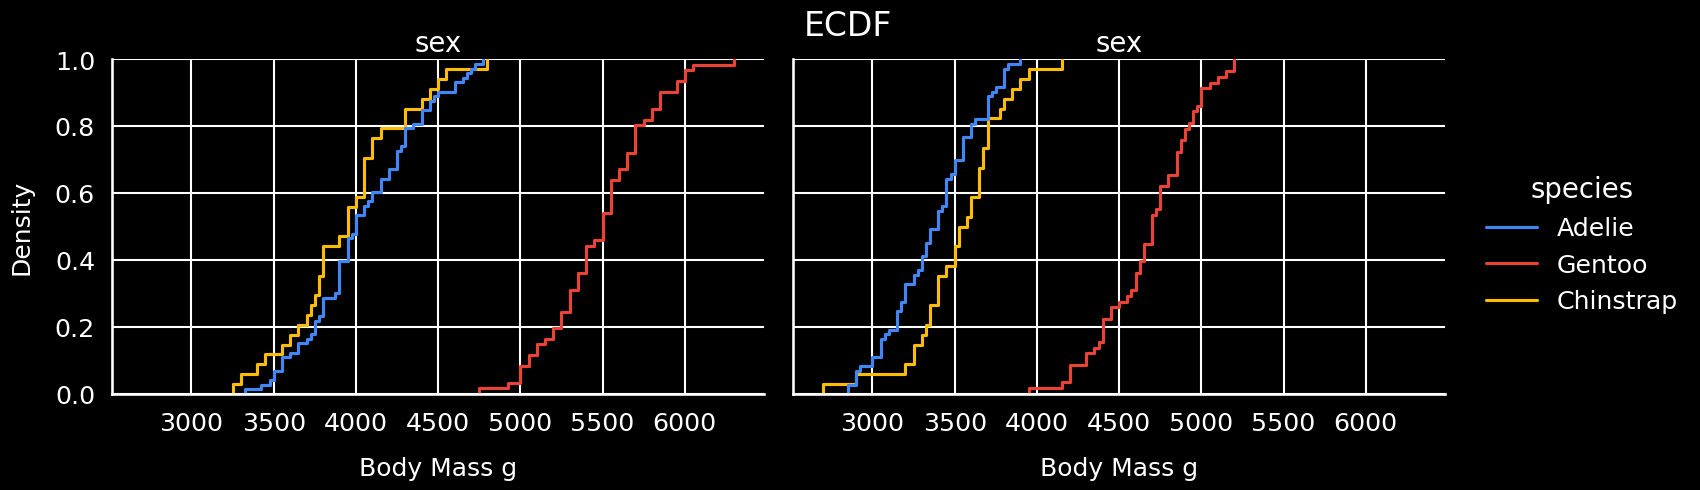

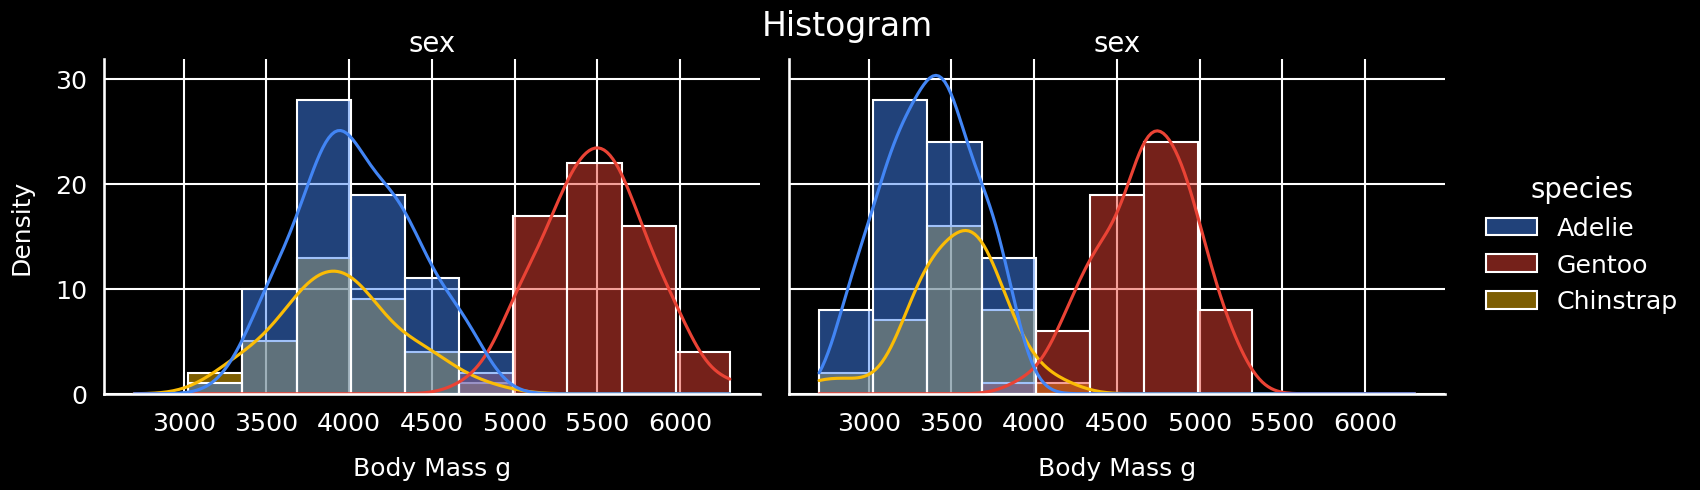

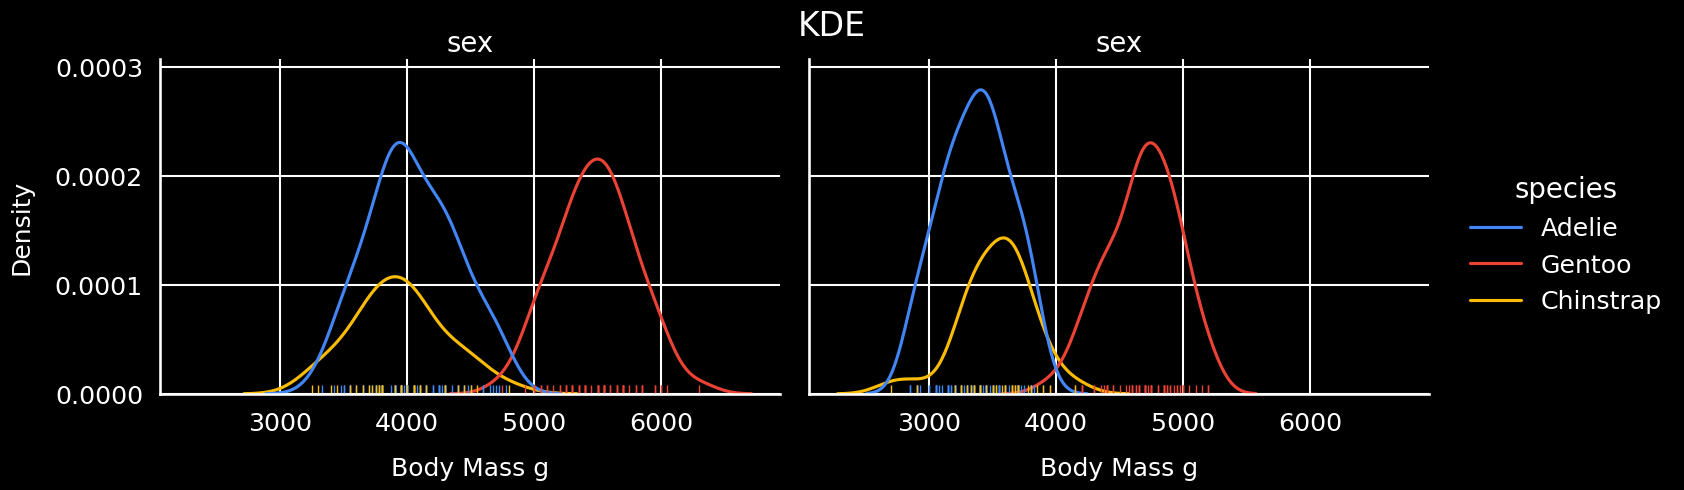

In [8]:
# ECDF
j = sns.displot(data=data, x='body_mass_g', hue='species', palette=google_three, kind='ecdf', legend=True, col='sex', col_wrap=2, aspect=1.5)
j.set_titles('sex')
j.figure.suptitle('ECDF')
j.set_xlabels('Body Mass g', labelpad=15, fontsize=18)
j.set_ylabels('Density', labelpad=15, fontsize=18)

# Histogram
k = sns.displot(data=data, x='body_mass_g', hue='species', palette=google_three, kind='hist', legend=True, col='sex', col_wrap=2, aspect=1.5, kde=True)
k.set_titles('sex')
k.figure.suptitle('Histogram')
k.set_xlabels('Body Mass g', labelpad=15, fontsize=18)
k.set_ylabels('Density', labelpad=15, fontsize=18)

# KDE
h = sns.displot(data=data, x='body_mass_g', hue='species', palette=google_three, kind='kde', legend=True, col='sex', col_wrap=2, aspect=1.5, rug=True)
h.set_titles('sex')
h.figure.suptitle('KDE')
h.set_xlabels('Body Mass g', labelpad=15, fontsize=18)
h.set_ylabels('Density', labelpad=15, fontsize=18)

### Lmplot

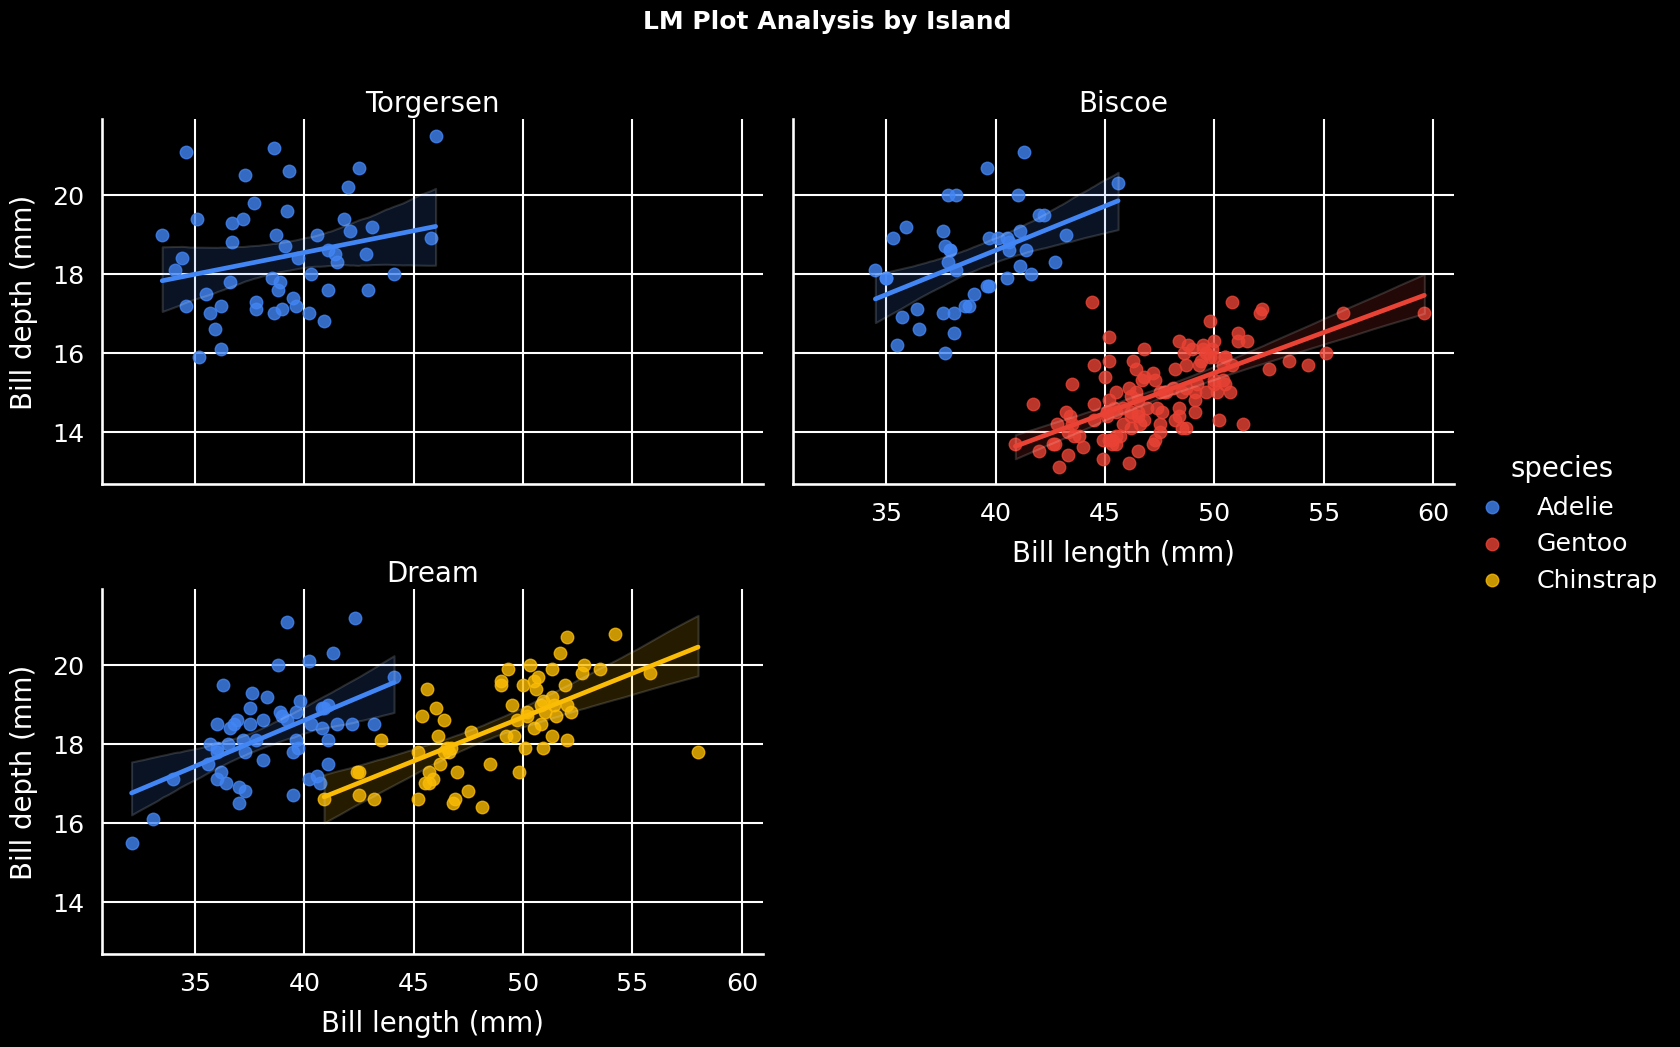

In [9]:
g = sns.lmplot(data=data, x="bill_length_mm", y="bill_depth_mm", hue="species", palette=google_three, aspect=1.5, col='island', col_wrap=2, row_order=['Dream', 'Torgersen', 'Biscoe'])
g.set_titles('{col_name}')
g.figure.suptitle('LM Plot Analysis by Island', fontsize=18, fontweight='bold', y=1.05)
g.set_ylabels('Bill depth (mm)', labelpad=10)
g.set_xlabels('Bill length (mm)', labelpad=10)

# DRAFT

In [37]:
data.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000000,-0.235053,0.656181,0.595110,0.054545
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916,-0.060354
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202,0.169675
body_mass_g,0.595110,-0.471916,0.871202,1.000000,0.042209
year,0.054545,-0.060354,0.169675,0.042209,1.000000


In [10]:
pivot_table = pd.pivot_table(data=data, index='species', columns=['sex', 'island'], values='body_mass_g', aggfunc='mean').round(2).fillna(0)
print(pivot_table)

sex         female                        male                   
island      Biscoe    Dream Torgersen   Biscoe    Dream Torgersen
species                                                          
Adelie     3369.32  3344.44   3395.83  4050.00  4045.54   4034.78
Chinstrap     0.00  3527.21      0.00     0.00  3938.97      0.00
Gentoo     4679.74     0.00      0.00  5484.84     0.00      0.00


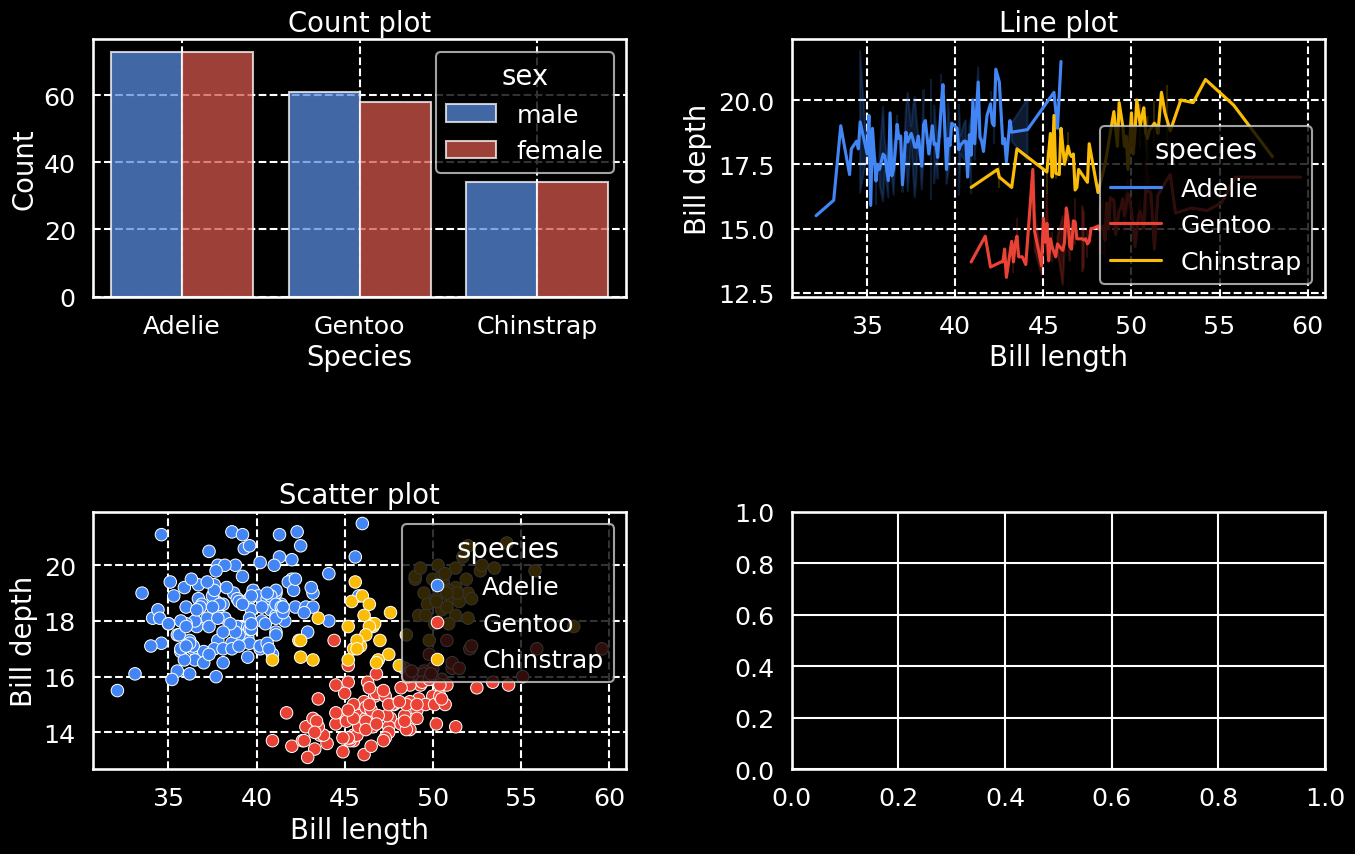

In [11]:
fig, axes = plt.subplots(2,2, figsize=(15, 10))

# # Creates a gradient starting from a custom color
# sns.color_palette("light:purple", as_cmap=False)
# sns.color_palette("dark:#33a02c", as_cmap=False)

# Blends two explicit hex codes or color names across a custom step-count
# sns.color_palette("blend:green,red", 10)
# sns.color_palette("deep")       # Default muted theme
# sns.color_palette("muted")      # Brighter, highly rich tones
# sns.color_palette("bright")     # High saturation colors
# sns.color_palette("pastel")     # Soft, washed-out tones
# sns.color_palette("dark")       # Low-luminance, rich colors
# sns.color_palette("colorblind")

#
# sns.set_theme(style="dark")
# sns.set_palette("seismic")
plt.style.use('dark_background')
# sns.set_theme(style="darkgrid")


# 2. Define Google's official brand hex codes
# Blue, Red, Yellow, Green
google_colors = ["#4285F4", "#EA4335", "#FBBC05", "#34A853"]

# 3. Set it globally
sns.set_palette(google_colors)


# Count plot
sns.countplot(data=data, x="species", ax=axes[0, 0], hue='sex', alpha=0.75)
axes[0, 0].set_title('Count plot')
axes[0, 0].set_xlabel('Species')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True, linestyle='--', which='major', axis='both')

# Line plot
sns.lineplot(data=data, x="bill_length_mm", y="bill_depth_mm", ax=axes[0, 1], hue='species', hue_order=['Adelie', 'Gentoo', 'Chinstrap'], errorbar='sd')
axes[0, 1].set_title('Line plot')
axes[0, 1].set_xlabel('Bill length')
axes[0, 1].set_ylabel('Bill depth')
axes[0, 1].grid(True, linestyle='--', which='major', axis='both')

# Scatter plot
sns.scatterplot(data=data, x='bill_length_mm', y='bill_depth_mm', ax=axes[1, 0], hue='species', hue_order=['Adelie', 'Gentoo', 'Chinstrap'])
axes[1, 0].set_title('Scatter plot')
axes[1, 0].set_xlabel('Bill length')
axes[1, 0].set_ylabel('Bill depth')
axes[1, 0].grid(True, linestyle='--', which='major', axis='both')

plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=3.0)
plt.show()

In [12]:
adelie['bill_length_mm'].std()

np.float64(2.663404848368619)

In [13]:
data.query('species == "Adelie"')['sex'].value_counts()

sex
male      73
female    73
Name: count, dtype: int64

In [14]:
data.query('species == "Adelie"')['sex']

0        male
1      female
2      female
3         NaN
4      female
        ...  
147    female
148    female
149      male
150    female
151      male
Name: sex, Length: 152, dtype: str

In [15]:
np.vstack([adelie['bill_length_mm'].iloc[15:45], gentoo['bill_length_mm'].iloc[15:45]])

array([[36.6, 38.7, 42.5, 34.4, 46. , 37.8, 37.7, 35.9, 38.2, 38.8, 35.3,
        40.6, 40.5, 37.9, 40.5, 39.5, 37.2, 39.5, 40.9, 36.4, 39.2, 38.8,
        42.2, 37.6, 39.8, 36.5, 40.8, 36. , 44.1, 37. ],
       [49.3, 42. , 49.2, 46.2, 48.7, 50.2, 45.1, 46.5, 46.3, 42.9, 46.1,
        44.5, 47.8, 48.2, 50. , 47.3, 42.8, 45.1, 59.6, 49.1, 48.4, 42.6,
        44.4, 44. , 48.7, 42.7, 49.6, 45.3, 49.6, 50.5]])

In [16]:
adelie.query('sex == "male"')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
13,Adelie,Torgersen,38.6,21.2,191.0,3800.0,male,2007
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,male,2007
...,...,...,...,...,...,...,...,...
143,Adelie,Dream,40.7,17.0,190.0,3725.0,male,2009
145,Adelie,Dream,39.0,18.7,185.0,3650.0,male,2009
146,Adelie,Dream,39.2,18.6,190.0,4250.0,male,2009
149,Adelie,Dream,37.8,18.1,193.0,3750.0,male,2009


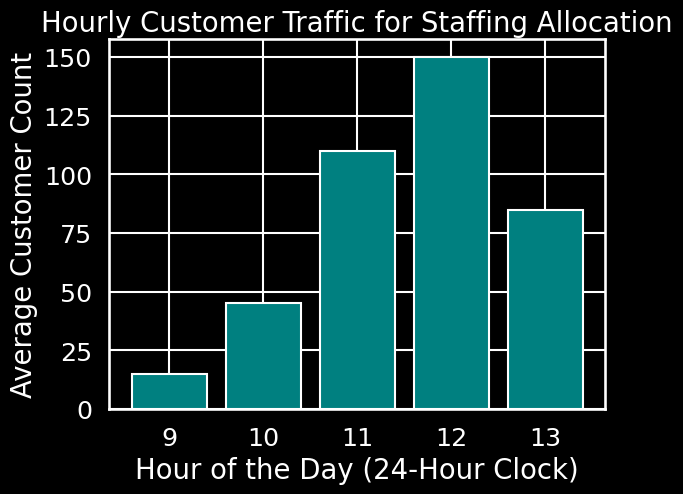

In [17]:
import matplotlib.pyplot as plt

# X: True numerical vector (Continuous hours of operation)
hours_of_day = [9, 10, 11, 12, 13]

# Y: True numerical vector (Average hourly foot traffic)
avg_customers = [15, 45, 110, 150, 85]

# Plotting the bars
plt.bar(hours_of_day, avg_customers, color='teal', width=0.8)

# Labeling the continuous numerical data
plt.xlabel('Hour of the Day (24-Hour Clock)')
plt.ylabel('Average Customer Count')
plt.title('Hourly Customer Traffic for Staffing Allocation')

# Ste

plt.show()


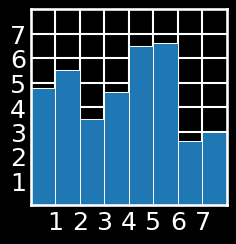

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data:
x = 0.5 + np.arange(8)
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# plot
fig, ax = plt.subplots()

ax.bar(x, y, width=1, edgecolor="white", linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

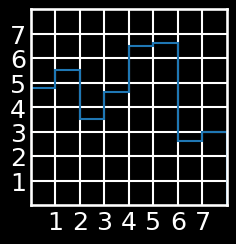

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# plot
fig, ax = plt.subplots()

ax.stairs(y, linewidth=1.5)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

In [20]:
adelie_120 = adelie['bill_length_mm'].iloc[0:121].ffill()
gentoo_120 = gentoo['bill_length_mm'].iloc[0:121].ffill()
print(adelie_120)
print(gentoo_120)

0      39.1
1      39.5
2      40.3
3      40.3
4      36.7
       ... 
116    38.6
117    37.3
118    35.7
119    41.1
120    36.2
Name: bill_length_mm, Length: 121, dtype: float64
152    46.1
153    50.0
154    48.7
155    50.0
156    47.6
       ... 
268    44.5
269    48.8
270    47.2
271    47.2
272    46.8
Name: bill_length_mm, Length: 121, dtype: float64


In [21]:
example = adelie_120.values + gentoo_120.values

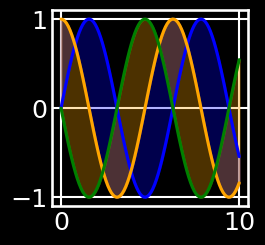

In [22]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = -np.sin(x)

fig, ax = plt.subplots()

# 1. Fill between y1 and y2
ax.fill_between(x, y1, y2, color='blue', alpha=0.3)

# 2. Fill between y2 and y3
ax.fill_between(x, y2, y3, color='orange', alpha=0.3)

# Add lines for context
ax.plot(x, y1, color='blue')
ax.plot(x, y2, color='orange')
ax.plot(x, y3, color='green')

plt.show()


In [23]:
data.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000
